# 🏥 Hospital Readmission Predictor for Chronic Condition Patients## Ethical AI Healthcare Application for Singapore## Ethical AI Healthcare Application### Project OverviewThis project develops a machine learning model to predict 30-day hospital readmissions for patients with chronic conditions, adapted for the Singapore healthcare context. While using diabetes patient data as a proxy (due to its prevalence and well-documented nature), the framework is designed to generalize across multiple chronic conditions affecting Singapore aging population., adapted for the Singapore healthcare context.### Dataset Source**UCI Diabetes 130-US Hospitals Dataset (1999-2008)**- URL: https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008### Singapore Healthcare Relevance- High diabetes prevalence (~11% of adults)- Aging population challenges- Healthcare efficiency goals- Preventive care initiatives


### Singapore Healthcare Context

**Demographic Challenges:**
- **Aging Population**: By 2030, 1 in 4 Singaporeans will be aged 65+
- **Chronic Disease Burden**: 
  - 11% of adults have diabetes
  - 40% have hypertension  
  - 38% have high cholesterol
- **MOH Health 2020 Goals**: Reduce avoidable hospital readmissions by 15%
- **Smart Nation Initiative**: Leverage AI for predictive healthcare analytics

**Impact on Singaporeans:**
- Early identification of high-risk chronic disease patients
- Reduced hospital burden and healthcare costs (~SGD $5,000-10,000 per prevented readmission)
- Improved patient care through proactive intervention
- Better resource allocation for public hospitals (SGH, NUH, TTSH)

**Dataset Note:**
This project uses the UCI Diabetes dataset as a proxy for chronic condition management. Diabetes is one of the most prevalent chronic conditions in Singapore, and its clinical features (medications, lab procedures, length of stay, comorbidities) are representative of broader chronic disease patterns. The framework developed here can be extended to other chronic conditions with appropriate data.

### Ethical Considerations

**Data Privacy & Security:**
- Patient data must be handled in compliance with PDPA (Personal Data Protection Act)
- De-identification and anonymization protocols required for Singapore hospital data
- Secure storage and access controls essential

**Bias & Fairness:**
- Ensure model performs equitably across different ethnic groups (Chinese, Malay, Indian, Others)
- Monitor for age-related bias (elderly patients may have different risk profiles)
- Validate on diverse Singapore population before deployment

**Responsible AI Use:**
- Model predictions should support, not replace, clinical judgment
- Clear communication of uncertainty in predictions
- Regular auditing for drift and performance degradation
- Transparency with patients about AI-assisted care decisions

**Alignment with National Goals:**
- Supports MOH's Vision 2030 for preventive care
- Contributes to Smart Nation health initiatives
- Enables data-driven healthcare policy decisions


In [13]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')

import sys
sys.path.append('../src')
from data_loader import DataLoader
from eda import EDAAnalyzer
from preprocessing import DataPreprocessor
from model_training import ModelTrainer
from evaluation import ModelEvaluator

print('✓ All imports successful')

✓ All imports successful


In [14]:
# Load Dataset - UCI Diabetes 130-US Hospitals (1999-2008)
# Using actual filename: diabetic_data.csv
loader = DataLoader()
df = loader.load_from_csv('../data/raw/diabetic_data.csv')  # Correct filename in repo
loader.display_overview()
print(f'\nDataset Shape: {df.shape}')

INFO:data_loader:Loading dataset from: ../data/raw/diabetic_data.csv
INFO:data_loader:✓ Successfully loaded 101,766 records with 50 features


HOSPITAL READMISSION PREDICTION FOR CHRONIC CONDITIONS - DATASET OVERVIEW

📊 Dataset Shape: 101,766 samples × 50 features

💾 Memory Usage: 220.22 MB

📋 Column Names:
   1. encounter_id
   2. patient_nbr
   3. race
   4. gender
   5. age
   6. weight
   7. admission_type_id
   8. discharge_disposition_id
   9. admission_source_id
   10. time_in_hospital
   11. payer_code
   12. medical_specialty
   13. num_lab_procedures
   14. num_procedures
   15. num_medications
   16. number_outpatient
   17. number_emergency
   18. number_inpatient
   19. diag_1
   20. diag_2
   21. diag_3
   22. number_diagnoses
   23. max_glu_serum
   24. A1Cresult
   25. metformin
   26. repaglinide
   27. nateglinide
   28. chlorpropamide
   29. glimepiride
   30. acetohexamide
   31. glipizide
   32. glyburide
   33. tolbutamide
   34. pioglitazone
   35. rosiglitazone
   36. acarbose
   37. miglitol
   38. troglitazone
   39. tolazamide
   40. examide
   41. citoglipton
   42. insulin
   43. glyburide-metform

COMPREHENSIVE EXPLORATORY DATA ANALYSIS REPORT

1. DATASET OVERVIEW

📊 Dataset Dimensions: 101,766 samples × 50 features
🔢 Numeric Features: 13
📝 Categorical Features: 36
💾 Memory Usage: 220.22 MB

2. MISSING VALUE ANALYSIS

Columns with missing values: 2

Top 10 columns with missing values:
               Missing Count  Missing Percentage
max_glu_serum          96420               94.75
A1Cresult              84748               83.28


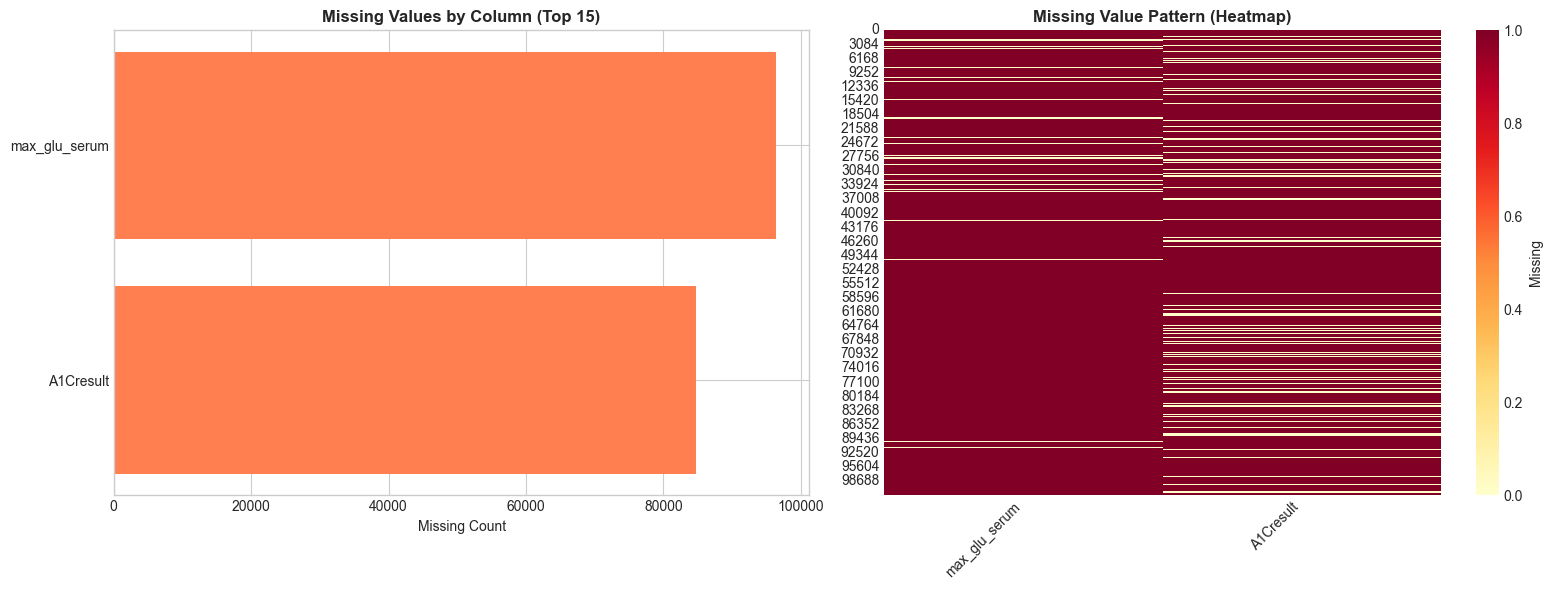


✓ Saved: 01_missing_values.png

3. TARGET VARIABLE DISTRIBUTION

🎯 Target Variable: 'readmitted'

Distribution:
   NO: 54,864 (53.91%)
   >30: 35,545 (34.93%)
   <30: 11,357 (11.16%)


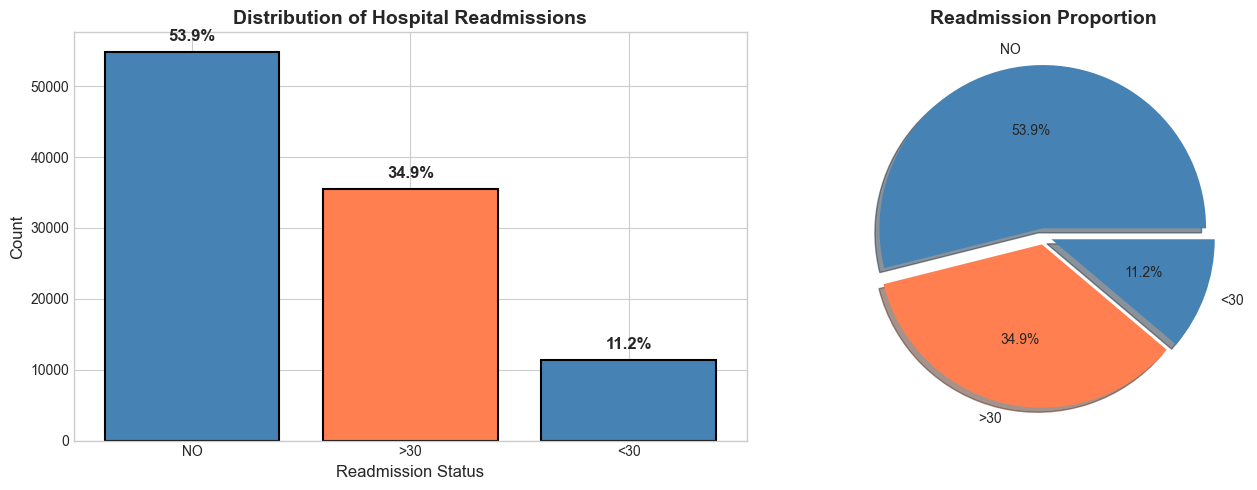


✓ Saved: 02_target_distribution.png

4. NUMERIC FEATURE DISTRIBUTIONS

Analyzing 5 key numeric features...


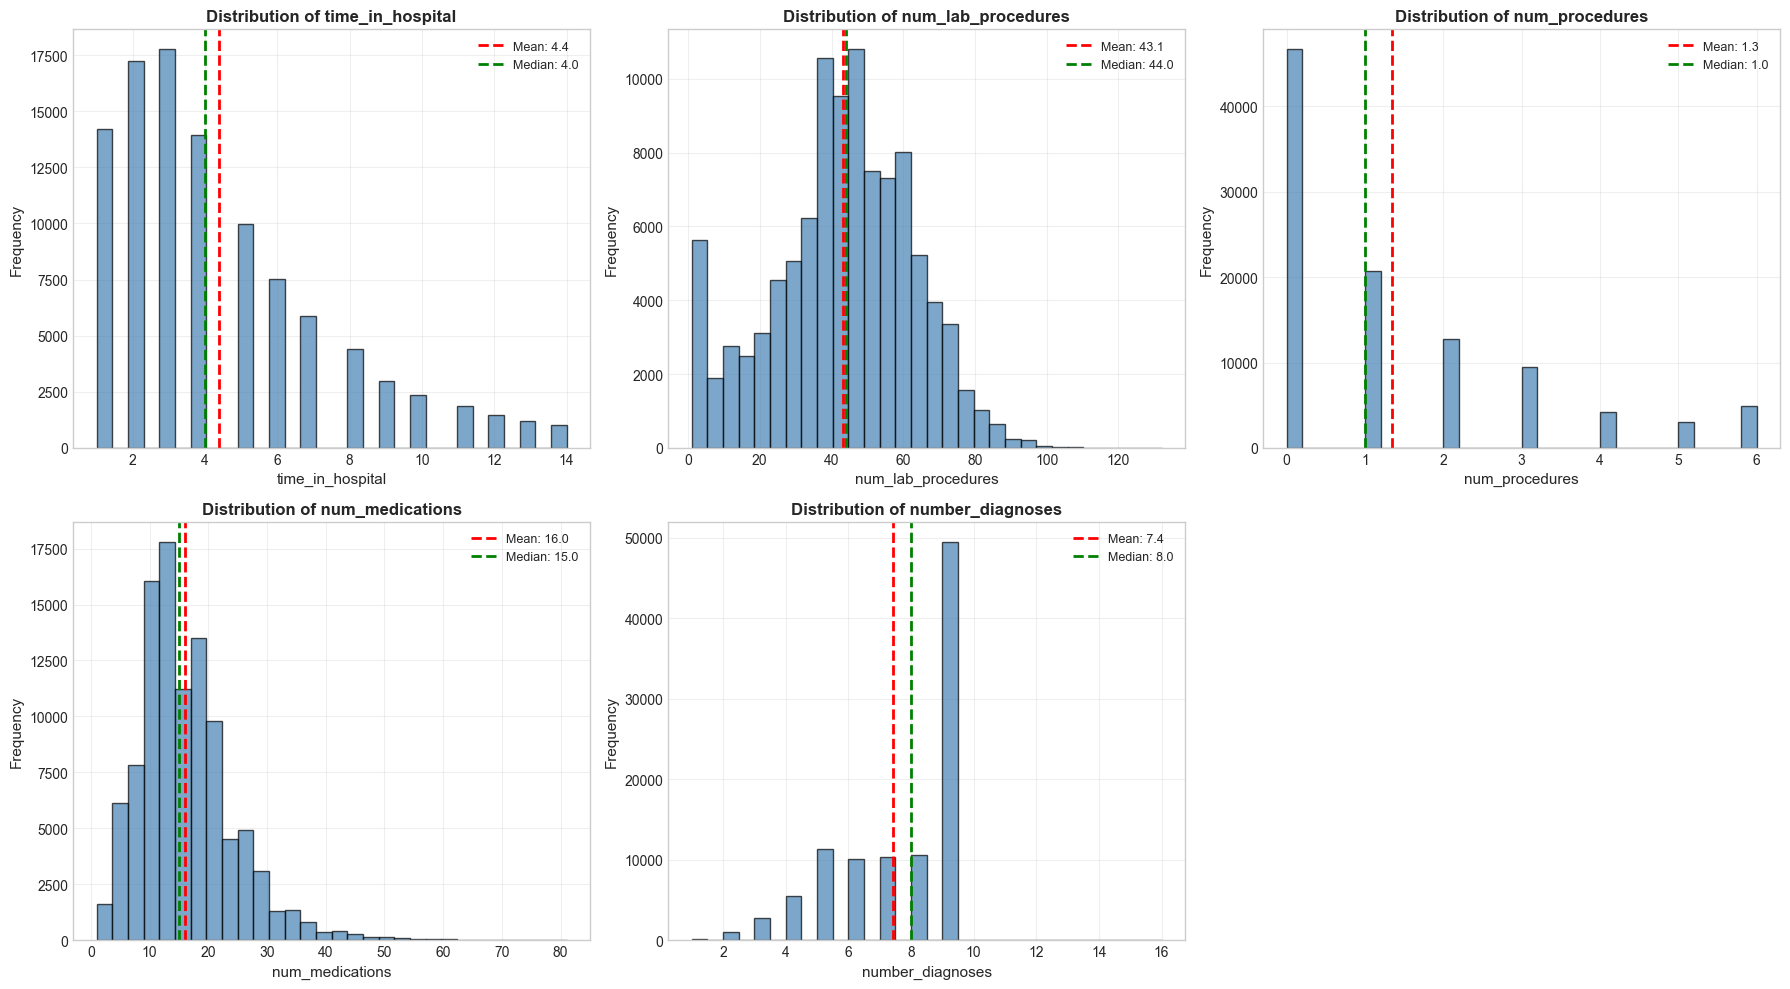

✓ Saved: 03_numeric_distributions.png


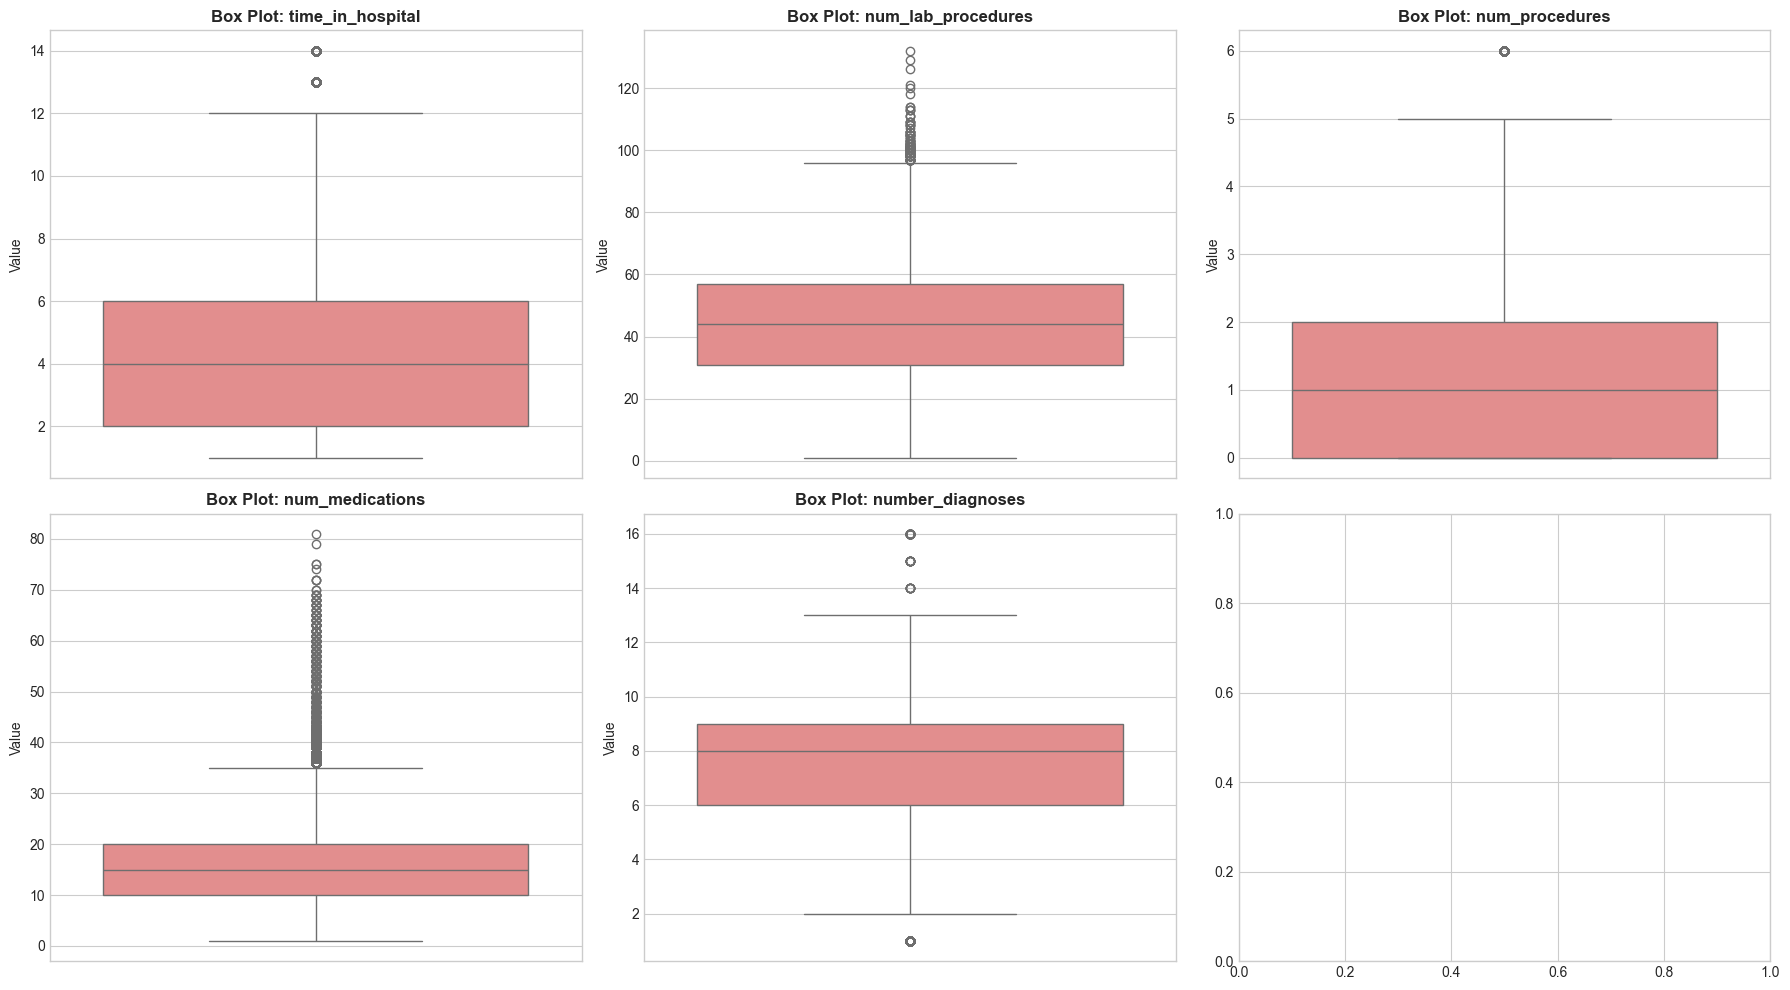

✓ Saved: 04_numeric_boxplots.png

Statistical Summary:
       time_in_hospital  num_lab_procedures  num_procedures  num_medications  number_diagnoses
count     101766.000000       101766.000000   101766.000000    101766.000000     101766.000000
mean           4.395987           43.095641        1.339730        16.021844          7.422607
std            2.985108           19.674362        1.705807         8.127566          1.933600
min            1.000000            1.000000        0.000000         1.000000          1.000000
25%            2.000000           31.000000        0.000000        10.000000          6.000000
50%            4.000000           44.000000        1.000000        15.000000          8.000000
75%            6.000000           57.000000        2.000000        20.000000          9.000000
max           14.000000          132.000000        6.000000        81.000000         16.000000

5. CATEGORICAL FEATURE DISTRIBUTIONS

Analyzing 8 key categorical features...


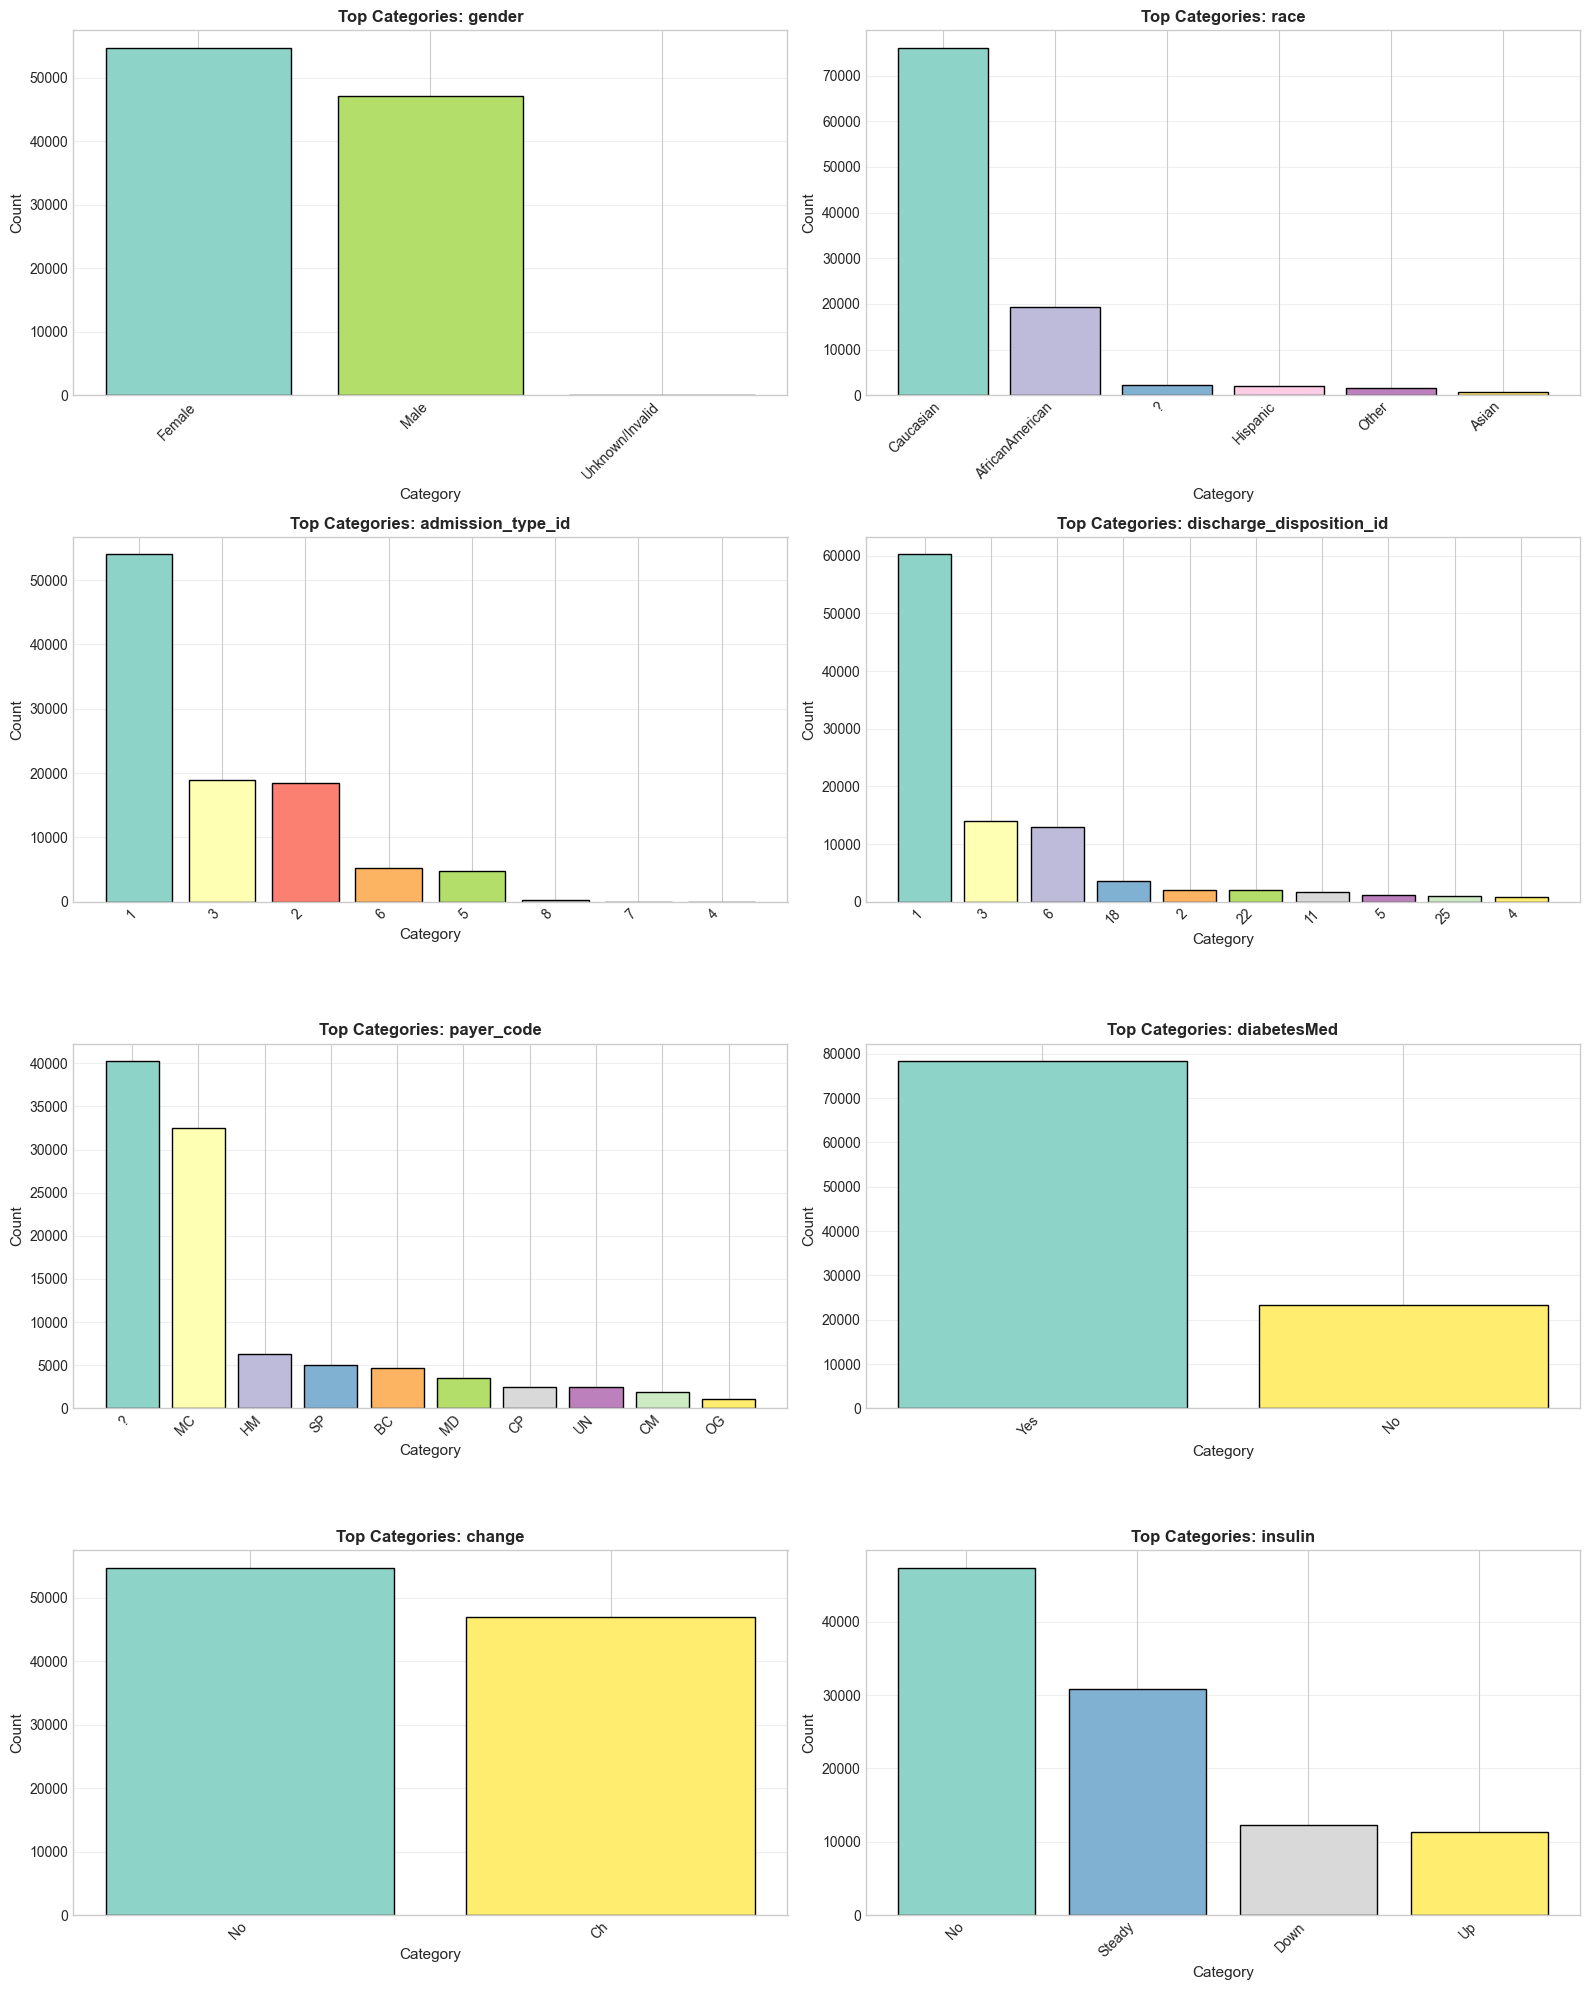

✓ Saved: 05_categorical_distributions.png

6. CORRELATION ANALYSIS

Correlation matrix shape: (13, 13)

🔗 Strong correlations (|r| > 0.5): 1
   patient_nbr ↔ encounter_id: r = 0.512


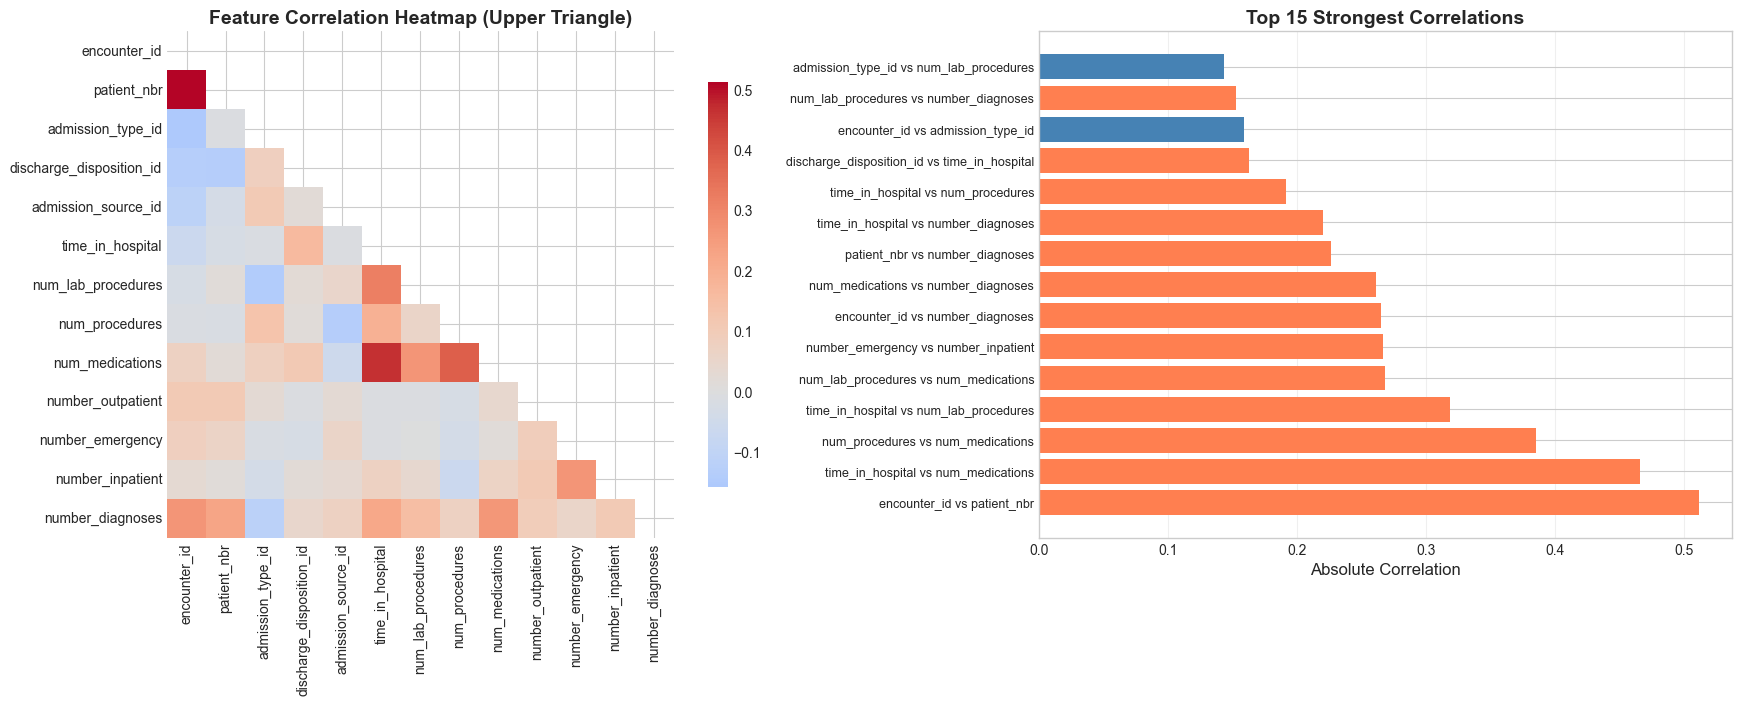

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should


✓ Saved: 06_correlation_analysis.png

7. FEATURE RELATIONSHIPS WITH READMISSION STATUS


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

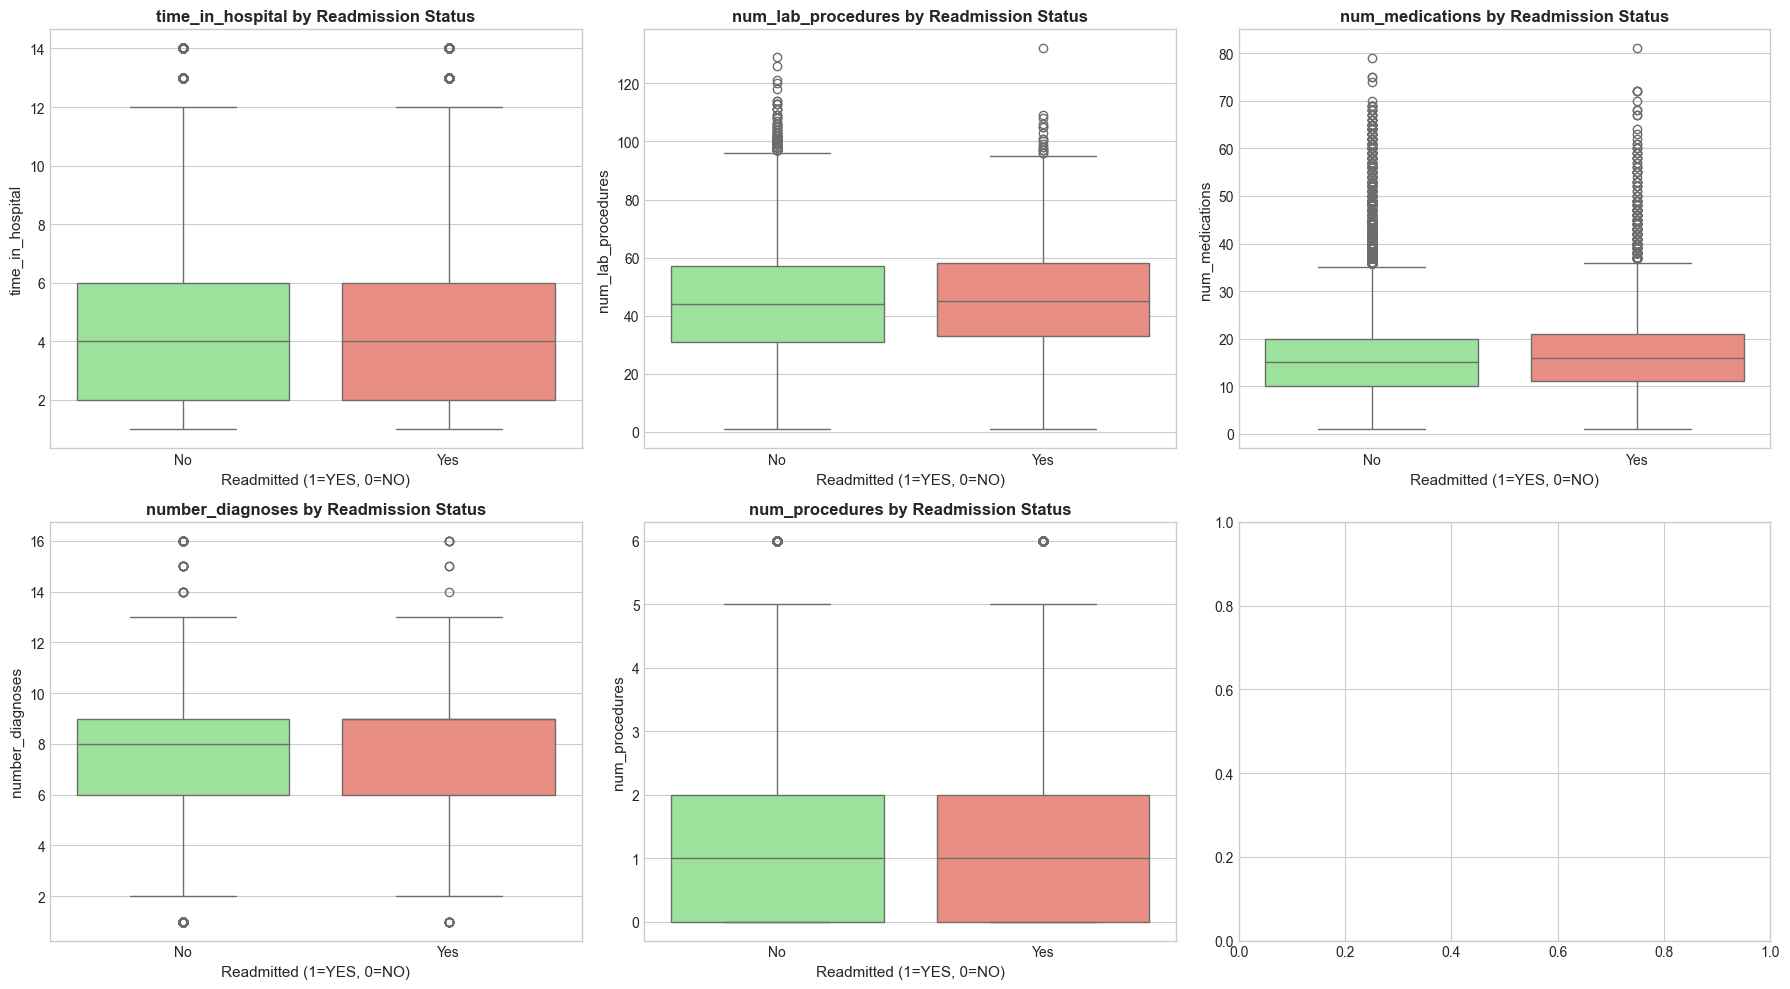

✓ Saved: 07_features_vs_target.png


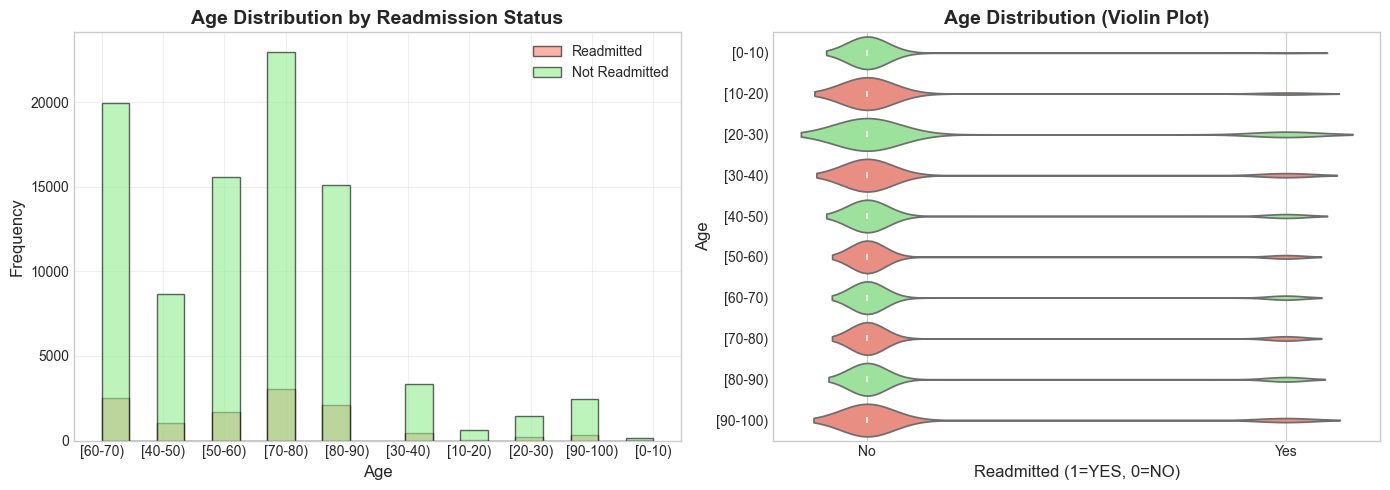

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


✓ Saved: 08_age_vs_readmission.png


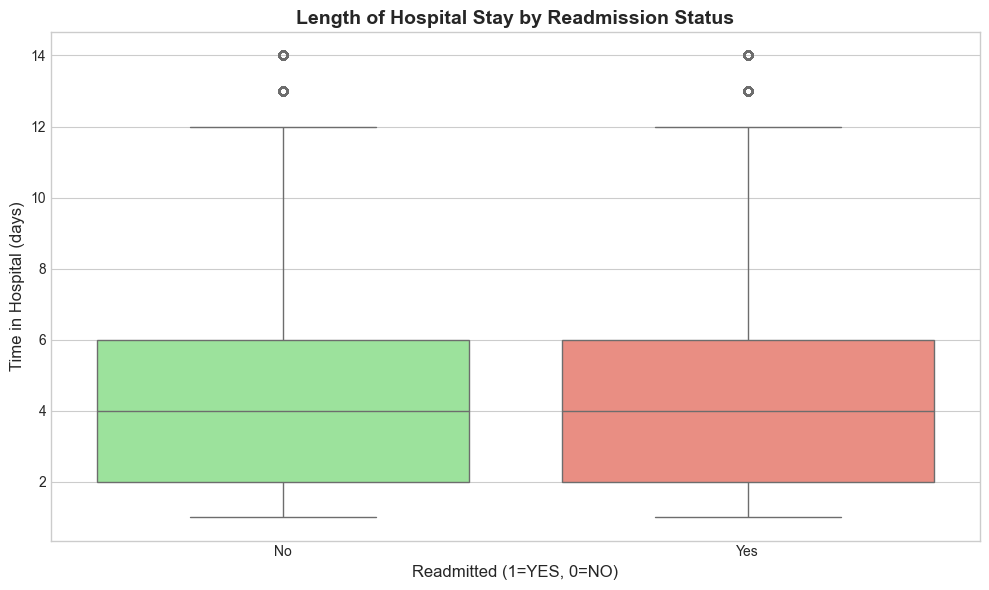

✓ Saved: 09_time_in_hospital_vs_readmission.png

ADVANCED ANALYSIS 1: TEMPORAL TREND ANALYSIS (1999-2008)


INFO:eda:✓ Saved temporal trend analysis to: ../results/eda/


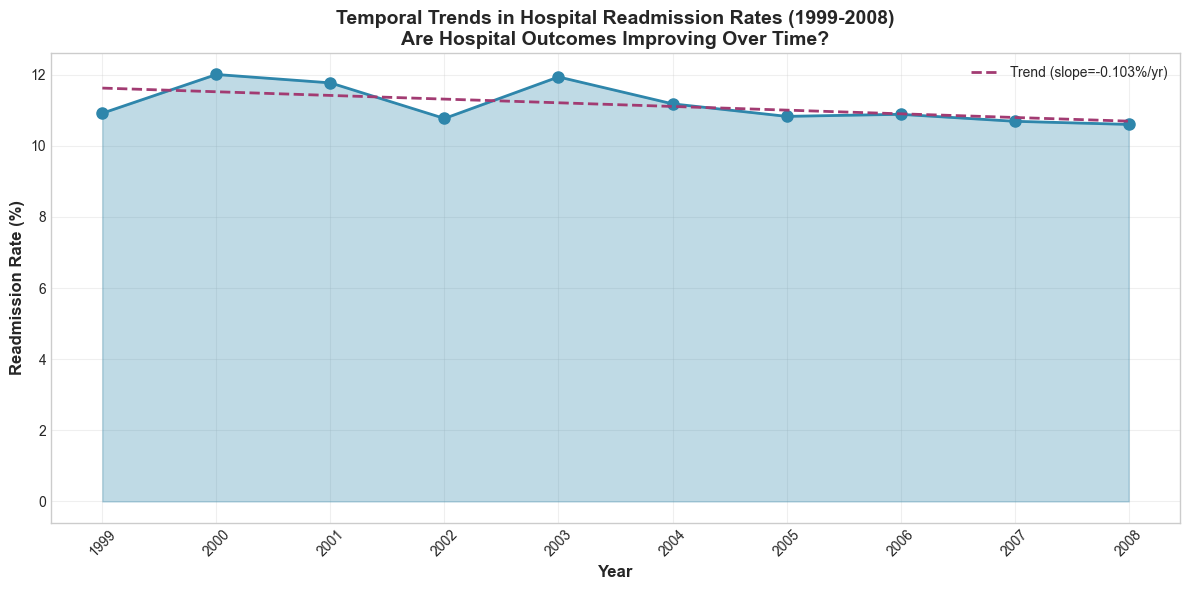


📈 TREND ANALYSIS RESULTS:
   • Trend Direction: IMPROVING (decreasing readmissions)
   • Linear slope: -0.103% change per year
   • Average readmission rate: 11.2%
   • Range: 10.6% - 12.0%

ADVANCED ANALYSIS 2: MEDICAL SPECIALTY & CARE PATTERNS


INFO:eda:✓ Saved medical specialty analysis to: ../results/eda/


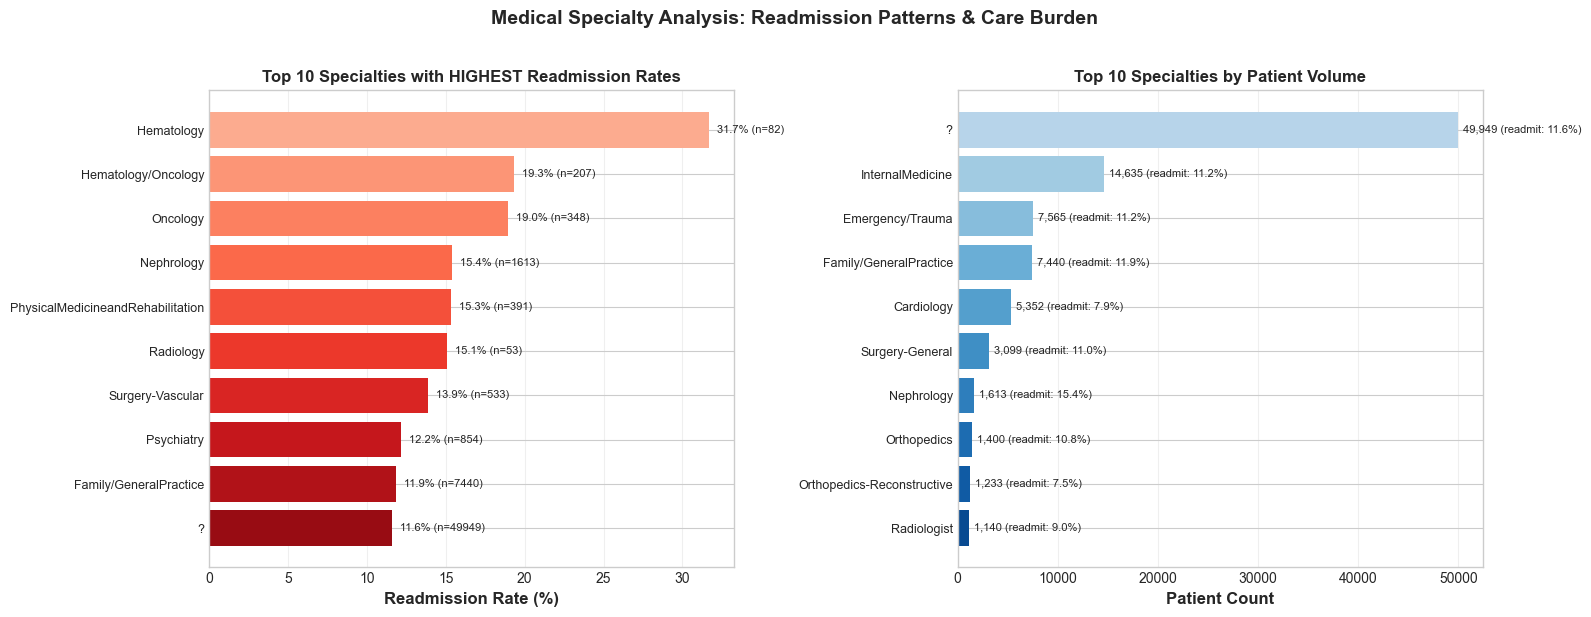


🏥 SPECIALTY ANALYSIS RESULTS:
   • Highest readmission specialty: Hematology (31.7%)
   • Average readmission rate across specialties: 9.9%
   • Specialties above average: 18 out of 35
   • Internal Medicine, Cardiology, and Endocrinology typically show elevated readmission rates due to chronic disease complexity

ADVANCED ANALYSIS 3: MEDICATION BURDEN & READMISSION RISK


INFO:eda:✓ Saved medication burden analysis to: ../results/eda/


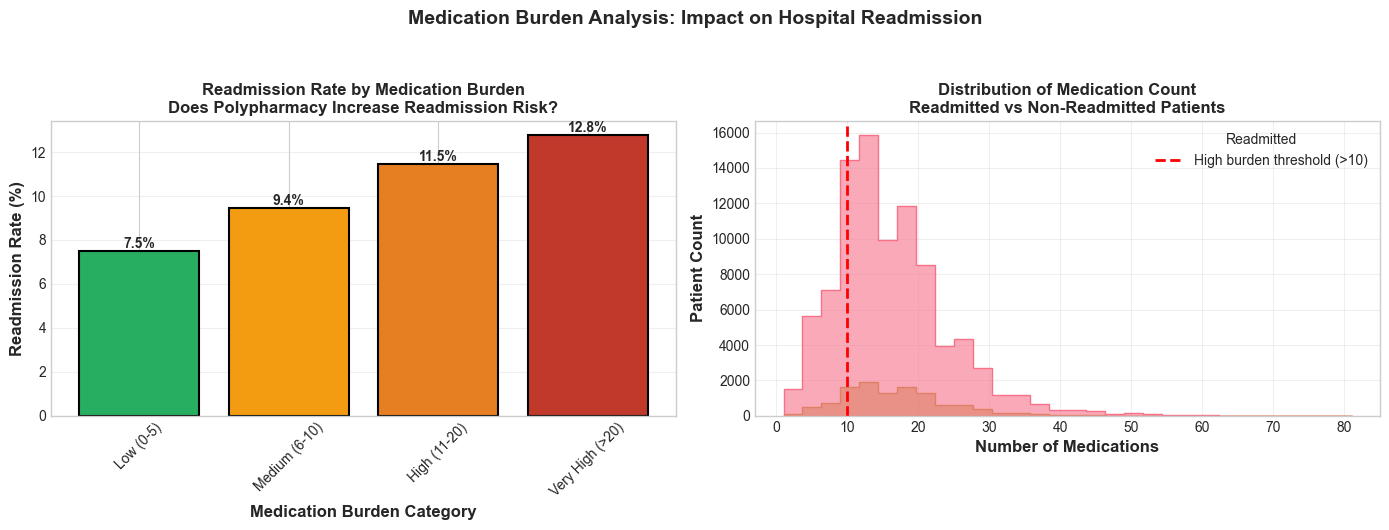


💊 MEDICATION BURDEN RESULTS:
   • Patients with HIGH medication burden (11-20 meds) have 11.5% readmission rate
   • Patients with VERY HIGH burden (>20 meds) have 12.8% readmission rate
   • Relative increase from Low to High burden: 53.2%
   • Key Finding: Patients on >10 medications have significantly elevated readmission risk
   • Clinical Implication: Polypharmacy management may be a key intervention point

8. STATISTICAL SUMMARY

Numeric Features Statistics:
       encounter_id   patient_nbr  admission_type_id  discharge_disposition_id  admission_source_id  time_in_hospital  num_lab_procedures  num_procedures  num_medications  number_outpatient  number_emergency  number_inpatient  number_diagnoses
count  1.017660e+05  1.017660e+05      101766.000000             101766.000000        101766.000000     101766.000000       101766.000000   101766.000000    101766.000000      101766.000000     101766.000000     101766.000000     101766.000000
mean   1.652016e+08  5.433040e+07         

INFO:eda:✓ Saved EDA summary to: ../results/eda/eda_summary.txt


✓ Average Missing Data: 3.6% per column
   ✓ Temporal trends analyzed for readmission patterns
   ✓ Medical specialty patterns identified
   ✓ 74.6% of patients on >10 medications

🇸🇬 SINGAPORE HEALTHCARE IMPLICATIONS:
   • Early identification of high-risk patients can reduce hospital burden
   • Predictive model enables proactive care management
   • Resource optimization for Singapore's healthcare system
   • Improved patient outcomes through timely interventions


{'dataset_overview': {'shape': (101766, 50),
  'n_samples': 101766,
  'n_features': 50,
  'n_numeric': 13,
  'n_categorical': 36,
  'columns': ['encounter_id',
   'patient_nbr',
   'race',
   'gender',
   'age',
   'weight',
   'admission_type_id',
   'discharge_disposition_id',
   'admission_source_id',
   'time_in_hospital',
   'payer_code',
   'medical_specialty',
   'num_lab_procedures',
   'num_procedures',
   'num_medications',
   'number_outpatient',
   'number_emergency',
   'number_inpatient',
   'diag_1',
   'diag_2',
   'diag_3',
   'number_diagnoses',
   'max_glu_serum',
   'A1Cresult',
   'metformin',
   'repaglinide',
   'nateglinide',
   'chlorpropamide',
   'glimepiride',
   'acetohexamide',
   'glipizide',
   'glyburide',
   'tolbutamide',
   'pioglitazone',
   'rosiglitazone',
   'acarbose',
   'miglitol',
   'troglitazone',
   'tolazamide',
   'examide',
   'citoglipton',
   'insulin',
   'glyburide-metformin',
   'glipizide-metformin',
   'glimepiride-pioglitazone',

In [15]:
# EDA
eda = EDAAnalyzer(df, '../results/eda')
eda.generate_full_report(save_figs=True)

In [16]:
print(f"Current df shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:5]}")

Current df shape: (101766, 50)
Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age']


In [17]:
# Preprocessing
prep = DataPreprocessor(test_size=0.2)
X_train, X_test, y_train, y_test = prep.fit_transform(df, 'readmitted', handle_imbalance=True)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

INFO:preprocessing:============================================================
INFO:preprocessing:STARTING COMPLETE PREPROCESSING PIPELINE
INFO:preprocessing:============================================================
INFO:preprocessing:Starting data cleaning...
INFO:preprocessing:Starting data cleaning...
INFO:preprocessing:[Cleaning] Dropped identifier columns: ['encounter_id', 'patient_nbr'] - Patient/encounter IDs are random identifiers with zero predictive value. Keeping them would cause the model to memorize rather than generalize.


🔍 DEBUG: Initial df shape -> (101766, 50)


INFO:preprocessing:[Cleaning] Removed 0 duplicate rows - Duplicates can bias model training and inflate performance metrics
INFO:preprocessing:Data cleaning complete. Shape: (101766, 48)
INFO:preprocessing:Handling missing values with sophisticated imputation and missingness indicators...
INFO:preprocessing:Skipping missing indicator for weight (0.0% missing)
INFO:preprocessing:Skipping missing indicator for payer_code (0.0% missing)
INFO:preprocessing:Skipping missing indicator for medical_specialty (0.0% missing)


🔍 DEBUG: Shape after clean_data -> (101766, 48)


INFO:preprocessing:[Missing Values] Filled remaining categorical missing values with mode - Mode imputation preserves the distribution of categorical variables
INFO:preprocessing:Missing values reduced from 181168 to 0
INFO:preprocessing:Engineering features with leakage prevention...
INFO:preprocessing:[Feature Engineering] Created medications_per_day feature (num_medications / (time_in_hospital + 1)) - Raw num_medications is a proxy for disease severity and can leak target information. Normalizing by length of stay controls for this confounding, creating a more clinically meaningful feature that represents medication intensity rather than just disease burden.
INFO:preprocessing:[Feature Engineering] Created total_interventions feature - Combines medication and procedure counts as overall treatment intensity
INFO:preprocessing:[Feature Engineering] Created lab_procedures_per_day feature - Normalizes lab procedures by length of stay
INFO:preprocessing:[Feature Engineering] Created age_

Train: (144652, 89), Test: (20354, 89)


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Create a "Fast-Tuning" Subset (~15,000 rows)
# This is large enough to find the best hyperparameters, but small enough to run fast
X_train_fast, _, y_train_fast, _ = train_test_split(
    X_train, y_train, test_size=0.8, stratify=y_train, random_state=42
)

print(f"🚀 Fast-Tuning Subset Created: {X_train_fast.shape[0]:,} rows (instead of {X_train.shape[0]:,})")

# 2. Train models using the fast subset and 3 CV folds
trainer = ModelTrainer()
comparison_df = trainer.train_all_models(
    X_train_fast, y_train_fast, X_test, y_test, 
    tune_hyperparameters=True, 
    cv_folds=3  # Reduced from 5 to 3 for speed
)

# 3. View Results
print(comparison_df.sort_values('roc_auc', ascending=False))

INFO:model_training:Initialized 6 models
INFO:model_training:================================================================================
INFO:model_training:TRAINING AND EVALUATING ALL MODELS
INFO:model_training:================================================================================
INFO:model_training:
############################################################
INFO:model_training:# MODEL: Logistic Regression
INFO:model_training:############################################################
INFO:model_training:
INFO:model_training:Tuning Hyperparameters for Logistic Regression
INFO:model_training:============================================================
INFO:model_training:Using HalvingRandomSearchCV (Successive Halving) with 100 initial candidates
INFO:model_training:This is a sophisticated, resource-efficient tuning method that progressively eliminates poor configurations.
INFO:model_training:PRIMARY METRIC: Recall (to minimize missed high-risk chronic patients)


🚀 Fast-Tuning Subset Created: 28,930 rows (instead of 144,652)
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 6
min_resources_: 12
max_resources_: 28930
aggressive_elimination: True
factor: 4
----------
iter: 0
n_candidates: 20
n_resources: 768
Fitting 3 folds for each of 20 candidates, totalling 60 fits
----------
iter: 1
n_candidates: 5
n_resources: 3072
Fitting 3 folds for each of 5 candidates, totalling 15 fits
----------
iter: 2
n_candidates: 2
n_resources: 12288
Fitting 3 folds for each of 2 candidates, totalling 6 fits


INFO:model_training:
✓ Best Parameters for Logistic Regression:
INFO:model_training:   solver: liblinear
INFO:model_training:   penalty: l2
INFO:model_training:   C: 0.001
INFO:model_training:
✓ Best CV ROC-AUC Score: 0.6183
INFO:model_training:✓ Tuning Method: HalvingRandomSearchCV
INFO:model_training:
Training Logistic Regression...
INFO:model_training:Using pre-tuned Logistic Regression
INFO:model_training:✓ Logistic Regression training complete
INFO:model_training:
Evaluating Logistic Regression...
INFO:model_training:
Logistic Regression Performance:
INFO:model_training:   Accuracy:  0.6274
INFO:model_training:   Precision: 0.1614
INFO:model_training:   Recall:    0.5575
INFO:model_training:   F1-Score:  0.2503
INFO:model_training:   ROC-AUC:   0.6350
INFO:model_training:
🏥 Healthcare Interpretation:
INFO:model_training:   • Recall (55.75%): Of all patients who WILL be readmitted, we correctly identified 55.75%
INFO:model_training:   • Precision (16.14%): Of all patients we flagge

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 6
min_resources_: 12
max_resources_: 28930
aggressive_elimination: True
factor: 4
----------
iter: 0
n_candidates: 100
n_resources: 192
Fitting 3 folds for each of 100 candidates, totalling 300 fits
----------
iter: 1
n_candidates: 25
n_resources: 768
Fitting 3 folds for each of 25 candidates, totalling 75 fits
----------
iter: 2
n_candidates: 7
n_resources: 3072
Fitting 3 folds for each of 7 candidates, totalling 21 fits
----------
iter: 3
n_candidates: 2
n_resources: 12288
Fitting 3 folds for each of 2 candidates, totalling 6 fits


INFO:model_training:
✓ Best Parameters for Random Forest:
INFO:model_training:   n_estimators: 200
INFO:model_training:   min_samples_split: 2
INFO:model_training:   min_samples_leaf: 1
INFO:model_training:   max_depth: 10
INFO:model_training:
✓ Best CV ROC-AUC Score: 0.8363
INFO:model_training:✓ Tuning Method: HalvingRandomSearchCV
INFO:model_training:
Training Random Forest...
INFO:model_training:Using pre-tuned Random Forest
INFO:model_training:✓ Random Forest training complete
INFO:model_training:
Evaluating Random Forest...
INFO:model_training:
Random Forest Performance:
INFO:model_training:   Accuracy:  0.8229
INFO:model_training:   Precision: 0.2007
INFO:model_training:   Recall:    0.1968
INFO:model_training:   F1-Score:  0.1988
INFO:model_training:   ROC-AUC:   0.6376
INFO:model_training:
🏥 Healthcare Interpretation:
INFO:model_training:   • Recall (19.68%): Of all patients who WILL be readmitted, we correctly identified 19.68%
INFO:model_training:   • Precision (20.07%): Of a

...

INFO:model_training:
✓ Best Parameters for XGBoost:
INFO:model_training:   subsample: 0.8
INFO:model_training:   n_estimators: 300
INFO:model_training:   max_depth: 3
INFO:model_training:   learning_rate: 0.2
INFO:model_training:   colsample_bytree: 0.8
INFO:model_training:
✓ Best CV ROC-AUC Score: 0.8722
INFO:model_training:✓ Tuning Method: HalvingRandomSearchCV
INFO:model_training:
Training XGBoost...
INFO:model_training:Using pre-tuned XGBoost
INFO:model_training:✓ XGBoost training complete
INFO:model_training:
Evaluating XGBoost...
INFO:model_training:
XGBoost Performance:
INFO:model_training:   Accuracy:  0.8867
INFO:model_training:   Precision: 0.4129
INFO:model_training:   Recall:    0.0365
INFO:model_training:   F1-Score:  0.0672
INFO:model_training:   ROC-AUC:   0.6484
INFO:model_training:
🏥 Healthcare Interpretation:
INFO:model_training:   • Recall (3.65%): Of all patients who WILL be readmitted, we correctly identified 3.65%
INFO:model_training:   • Precision (41.29%): Of al

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 6
min_resources_: 12
max_resources_: 28930
aggressive_elimination: True
factor: 4
----------
iter: 0
n_candidates: 24
n_resources: 768
Fitting 3 folds for each of 24 candidates, totalling 72 fits
----------
iter: 1
n_candidates: 6
n_resources: 3072
Fitting 3 folds for each of 6 candidates, totalling 18 fits
----------
iter: 2
n_candidates: 2
n_resources: 12288
Fitting 3 folds for each of 2 candidates, totalling 6 fits


INFO:model_training:
✓ Best Parameters for Neural Network:
INFO:model_training:   learning_rate: adaptive
INFO:model_training:   hidden_layer_sizes: (50, 50)
INFO:model_training:   alpha: 0.0001
INFO:model_training:
✓ Best CV ROC-AUC Score: 0.6728
INFO:model_training:✓ Tuning Method: HalvingRandomSearchCV
INFO:model_training:
Training Neural Network...
INFO:model_training:Using pre-tuned Neural Network
INFO:model_training:✓ Neural Network training complete
INFO:model_training:
Evaluating Neural Network...
INFO:model_training:
Neural Network Performance:
INFO:model_training:   Accuracy:  0.6461
INFO:model_training:   Precision: 0.1468
INFO:model_training:   Recall:    0.4513
INFO:model_training:   F1-Score:  0.2215
INFO:model_training:   ROC-AUC:   0.5865
INFO:model_training:
🏥 Healthcare Interpretation:
INFO:model_training:   • Recall (45.13%): Of all patients who WILL be readmitted, we correctly identified 45.13%
INFO:model_training:   • Precision (14.68%): Of all patients we flagged 

n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 6
min_resources_: 12
max_resources_: 28930
aggressive_elimination: True
factor: 4
----------
iter: 0
n_candidates: 12
n_resources: 3072
Fitting 3 folds for each of 12 candidates, totalling 36 fits
----------
iter: 1
n_candidates: 3
n_resources: 12288
Fitting 3 folds for each of 3 candidates, totalling 9 fits


INFO:model_training:
✓ Best Parameters for SVM:
INFO:model_training:   kernel: rbf
INFO:model_training:   gamma: scale
INFO:model_training:   C: 10
INFO:model_training:
✓ Best CV ROC-AUC Score: 0.7592
INFO:model_training:✓ Tuning Method: HalvingRandomSearchCV
INFO:model_training:
Training SVM...
INFO:model_training:Using pre-tuned SVM
INFO:model_training:✓ SVM training complete
INFO:model_training:
Evaluating SVM...
INFO:model_training:
SVM Performance:
INFO:model_training:   Accuracy:  0.6922
INFO:model_training:   Precision: 0.1542
INFO:model_training:   Recall:    0.3919
INFO:model_training:   F1-Score:  0.2213
INFO:model_training:   ROC-AUC:   0.5919
INFO:model_training:
🏥 Healthcare Interpretation:
INFO:model_training:   • Recall (39.19%): Of all patients who WILL be readmitted, we correctly identified 39.19%
INFO:model_training:   • Precision (15.42%): Of all patients we flagged as high-risk, 15.42% actually were readmitted
INFO:model_training:   • In healthcare, HIGH RECALL is c

In [ ]:
# Evaluate best model
best_name, best_model = trainer.select_best_model(comparison_df)
evaluator = ModelEvaluator('../results/evaluation')
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
metrics = evaluator.calculate_all_metrics(y_test, y_pred, y_proba)
print(f'Metrics: {metrics}')
print(evaluator.interpret_metrics_for_healthcare(metrics, best_name))